# Squat Data Pipeline & Balancing

Data preparation for the Squat form-error models on the Fitness-AQA dataset: the train/val/test splits, class-imbalance handling, the frame-sampling and spatial-preprocessing contract, and train-time augmentation.

The official Fitness-AQA splits are used verbatim (no clips dropped, no resampling) so F1 is comparable to the published results. Class imbalance is handled in the loss via `pos_weight` rather than by re-sampling the data.

In [1]:
import os, json
import numpy as np
import torch
import matplotlib.pyplot as plt

_d = os.getcwd()
while _d != os.path.dirname(_d):
    if os.path.isdir(os.path.join(_d, "Fitness-AQA")) and os.path.isdir(os.path.join(_d, "backend")):
        break
    _d = os.path.dirname(_d)
os.chdir(_d)
BASE = ("Fitness-AQA/Fitness-AQA_dataset_release-20260518T073812Z-3-001/"
        "Fitness-AQA_dataset_release/Squat/Labeled_Dataset")
VIDS = os.path.join(BASE, "videos_extracted", "videos")

from backend.training.aqa.datasets.transforms import (
    spatial_val, spatial_train, uniform_sample_indices, KINETICS_MEAN, KINETICS_STD)
from backend.services.clip_decode import decode_clip_cv2, get_frame_count_and_fps

kfe = json.load(open(os.path.join(BASE, "Labels/error_knees_forward.json")))
kie = json.load(open(os.path.join(BASE, "Labels/error_knees_inward.json")))
train = list(json.load(open(os.path.join(BASE, "Splits/train_keys.json"))))
print(f"train clips: {len(train)}")

_MEAN = torch.tensor(KINETICS_MEAN).view(3, 1, 1, 1)
_STD = torch.tensor(KINETICS_STD).view(3, 1, 1, 1)
def denorm(clip_ctHW, t):  # [C,T,112,112] normalized -> HWC uint8 frame t
    v = (clip_ctHW * _STD + _MEAN).clamp(0, 1)
    return (v[:, t].permute(1, 2, 0).numpy() * 255).astype(np.uint8)

train clips: 1136


## 1. Class imbalance and `pos_weight`

`BCEWithLogitsLoss(pos_weight=[w_KIE, w_KFE])` with `w = #neg / #pos` computed on the train split. KIE is rare and is up-weighted; KFE is common and is down-weighted. This corrects the imbalance without changing the official split.

KIE: 160 pos / 976 neg -> pos_weight 6.10
KFE: 782 pos / 354 neg -> pos_weight 0.45


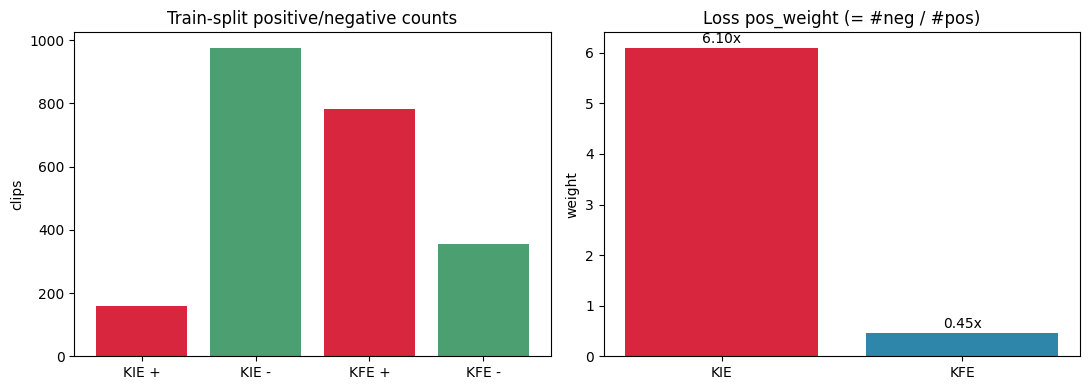

In [2]:
def pos_weight(label_map):
    pos = sum(1 for c in train if label_map.get(c)); neg = len(train) - pos
    return pos, neg, neg / pos
kie_pos, kie_neg, w_kie = pos_weight(kie)
kfe_pos, kfe_neg, w_kfe = pos_weight(kfe)
print(f"KIE: {kie_pos} pos / {kie_neg} neg -> pos_weight {w_kie:.2f}")
print(f"KFE: {kfe_pos} pos / {kfe_neg} neg -> pos_weight {w_kfe:.2f}")

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].bar(["KIE +", "KIE -", "KFE +", "KFE -"], [kie_pos, kie_neg, kfe_pos, kfe_neg],
           color=["#D7263D", "#4C9F70", "#D7263D", "#4C9F70"])
axs[0].set_title("Train-split positive/negative counts"); axs[0].set_ylabel("clips")
axs[1].bar(["KIE", "KFE"], [w_kie, w_kfe], color=["#D7263D", "#2E86AB"])
for i, w in enumerate([w_kie, w_kfe]): axs[1].text(i, w + 0.1, f"{w:.2f}x", ha="center")
axs[1].set_title("Loss pos_weight (= #neg / #pos)"); axs[1].set_ylabel("weight")
plt.tight_layout(); plt.show()

## 2. Frame sampling + spatial preprocessing
Each clip -> **32 frames** (uniform sampling) -> short-side resize to 128 -> **112x112
center crop** -> Kinetics-400 normalization. This is the exact contract the model sees
(train == serve — preprocessing parity is critical).

clip 46777_1: 73 frames @ 30fps -> sampled 32 -> model input (3, 32, 112, 112)


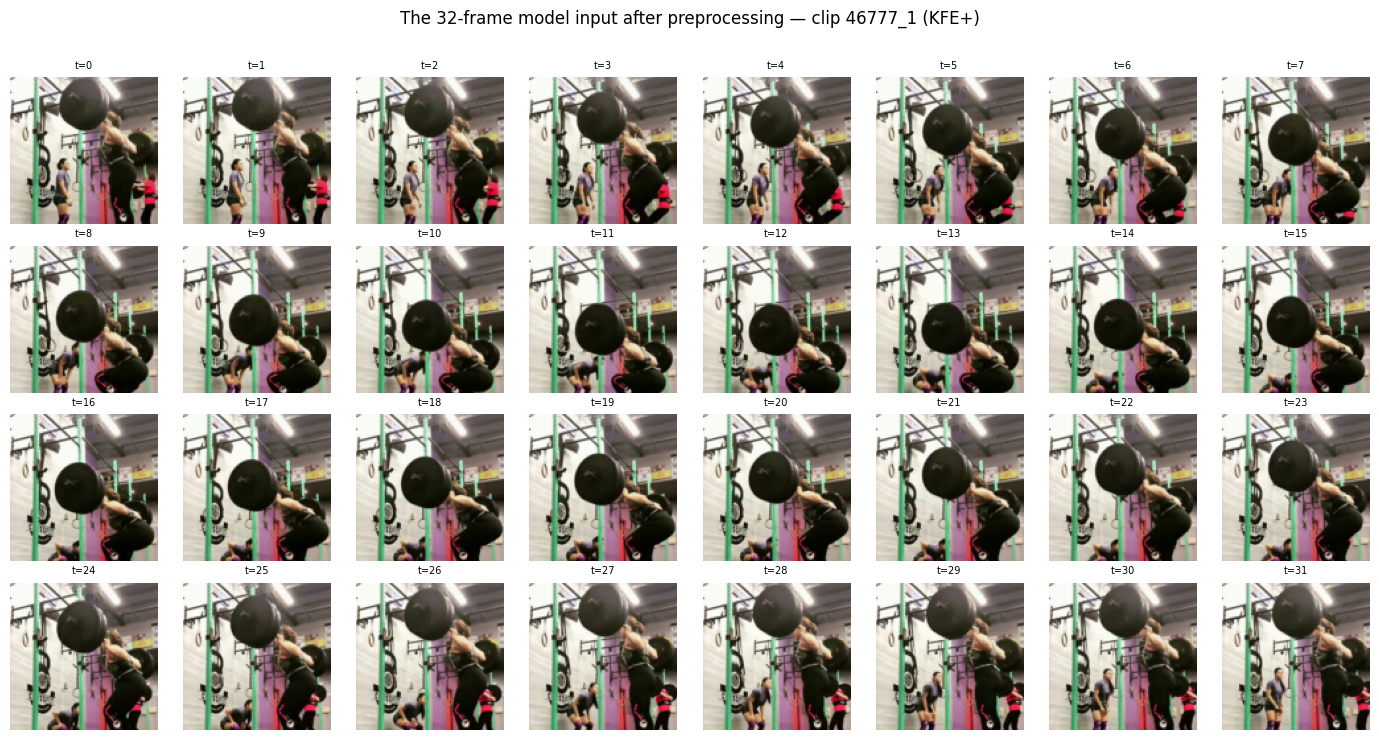

In [3]:
sample_clip = next(c for c in train if kfe.get(c) and os.path.exists(os.path.join(VIDS, f"{c}.mp4")))
p = os.path.join(VIDS, f"{sample_clip}.mp4")
n, fps = get_frame_count_and_fps(p)
idx = uniform_sample_indices(n, 32, jitter=0).clamp(0, max(n - 1, 0))
frames = decode_clip_cv2(p, idx)                 # [32,3,H,W] uint8 RGB
clip_val = spatial_val(frames)                   # [3,32,112,112] normalized
print(f"clip {sample_clip}: {n} frames @ {fps:.0f}fps -> sampled 32 -> model input {tuple(clip_val.shape)}")

# the 32-frame model-input sequence
fig, axes = plt.subplots(4, 8, figsize=(14, 7.5))
for t, ax in enumerate(axes.flat):
    ax.imshow(denorm(clip_val, t)); ax.axis("off"); ax.set_title(f"t={t}", fontsize=7)
fig.suptitle(f"The 32-frame model input after preprocessing — clip {sample_clip} (KFE+)", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

## 3. Train-time augmentation
Training uses a **random** spatial crop (`spatial_train`) for variety; inference uses the
**deterministic center crop** (`spatial_val`). Horizontal flip is OFF (it can swap left/
right knees → would corrupt KIE). Below: the same frame under 3 random train crops vs the
fixed val crop.

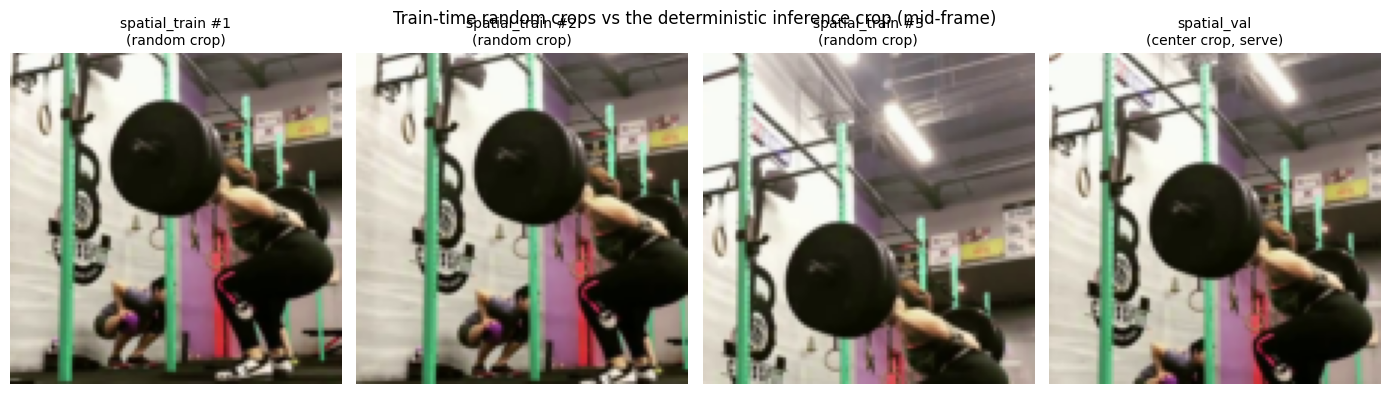

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i in range(3):
    aug = spatial_train(frames)
    axes[i].imshow(denorm(aug, 16)); axes[i].axis("off"); axes[i].set_title(f"spatial_train #{i+1}\n(random crop)", fontsize=10)
axes[3].imshow(denorm(clip_val, 16)); axes[3].axis("off"); axes[3].set_title("spatial_val\n(center crop, serve)", fontsize=10)
fig.suptitle("Train-time random crops vs the deterministic inference crop (mid-frame)", fontsize=12)
plt.tight_layout(); plt.show()

## Summary
- **Splits used verbatim** (official) — no clips dropped, no resampling → comparable to the paper.
- **Imbalance handled in the loss** via `pos_weight` (KIE up-weighted ~6x, KFE ~0.45x),
  not by re-sampling.
- **Preprocessing contract:** 32-frame uniform sampling -> 112x112 center crop -> Kinetics norm,
  identical at train and serve time (parity is the #1 correctness rule).
- **Augmentation:** random crop at train time; flip OFF (KIE is left/right-sensitive).

In [5]:
print("KIE pos_weight {:.2f}x | KFE pos_weight {:.2f}x".format(w_kie, w_kfe))

KIE pos_weight 6.10x | KFE pos_weight 0.45x
